In [1]:
import pandas as pd
data=pd.read_csv("../data/House Price Prediction Dataset.csv",index_col=0)
print(data.head())
print("hello")


    Area  Bedrooms  Bathrooms  Floors  YearBuilt  Location  Condition Garage  \
Id                                                                             
1   1360         5          4       3       1970  Downtown  Excellent     No   
2   4272         5          4       3       1958  Downtown  Excellent     No   
3   3592         2          2       3       1938  Downtown       Good     No   
4    966         4          2       2       1902  Suburban       Fair    Yes   
5   4926         1          4       2       1975  Downtown       Fair    Yes   

     Price  
Id          
1   149919  
2   424998  
3   266746  
4   244020  
5   636056  
hello


In [2]:
#No null values detected

encoded_data = pd.get_dummies(
    data,
    columns=["Garage","Location","Condition"],
    drop_first=True
)
print(encoded_data.columns)


Index(['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Price',
       'Garage_Yes', 'Location_Rural', 'Location_Suburban', 'Location_Urban',
       'Condition_Fair', 'Condition_Good', 'Condition_Poor'],
      dtype='object')


In [3]:
#data.info()
#print(data[["price"],["Area"]].corr())
print(encoded_data.corr()["Price"].sort_values(ascending=False))


Price                1.000000
Floors               0.055890
Condition_Fair       0.049218
Location_Suburban    0.040303
YearBuilt            0.004845
Garage_Yes           0.002842
Location_Rural       0.001890
Area                 0.001542
Bedrooms            -0.003471
Bathrooms           -0.015737
Condition_Good      -0.017179
Condition_Poor      -0.018437
Location_Urban      -0.038312
Name: Price, dtype: float64


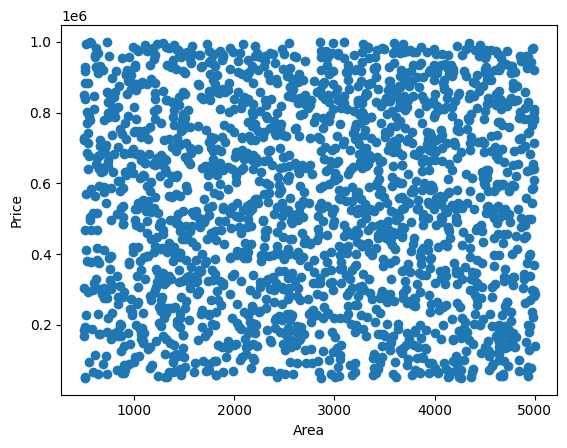

In [4]:
import matplotlib.pyplot as plt

plt.scatter(data["Area"], data["Price"])
plt.xlabel("Area")
plt.ylabel("Price")
plt.show()

In [5]:
#encoded_data["Price_per_room"]=encoded_data["Price"]/encoded_data["Bedrooms"]
encoded_data["Basketball"]=((encoded_data["Garage_Yes"] == True ) & (encoded_data["Area"]> 2000)).astype(int)



In [6]:
#encoded_data
#prepare Data for Training (test and spilt)
X=encoded_data.drop("Price",axis=1)
y=encoded_data["Price"]
X.head(5)
y.head(5)



Id
1    149919
2    424998
3    266746
4    244020
5    636056
Name: Price, dtype: int64

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("yes")

yes
